In [15]:
from pathlib import Path
import numpy as np
from pprint import pprint
from PIL import Image
import matplotlib.pyplot as plt

from bovw import BagOfVisualWordsClassifier, BoVWConfig

In [16]:
def get(feature_extractor, vocabulary_size, use_tfidf, method):
    dataset_root = Path('caltech101_reduced')

    config = BoVWConfig(
        feature_extractor=feature_extractor,
        vocabulary_size=vocabulary_size,
        max_descriptors_per_image=250,
        max_vocabulary_descriptors=20000,
        random_state=42,
    )
    model = BagOfVisualWordsClassifier(config)
    model.fit(dataset_root / 'train')

    test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])

    model.index_dataset(test_images, use_tfidf=use_tfidf)

    results = model.evaluate_retrieval(test_images, top_k=8, metric=method, use_tfidf=use_tfidf)
    print('Mean Precision@8: {:.4f}'.format(results['mean_precision_at_k']))
    print('Mean Recall@8: {:.4f}'.format(results['mean_recall_at_k']))
    print('Mean Average Precision (mAP): {:.4f}'.format(results['mean_average_precision']))

    return results['mean_precision_at_k']

In [17]:
x = ['SIFT', 'ORB', 'AKAZE', 'BRISK', 'KAZE']
y = []
for i in x:
    print(i)
    y.append(get(i, 100, True, "cosine"))

SIFT
Mean Precision@8: 0.3397
Mean Recall@8: 0.3175
Mean Average Precision (mAP): 0.4088
ORB
Mean Precision@8: 0.2826
Mean Recall@8: 0.2687
Mean Average Precision (mAP): 0.3255
AKAZE
Mean Precision@8: 0.2527
Mean Recall@8: 0.2354
Mean Average Precision (mAP): 0.3164
BRISK
Mean Precision@8: 0.2663
Mean Recall@8: 0.2533
Mean Average Precision (mAP): 0.3215
KAZE
Mean Precision@8: 0.3315
Mean Recall@8: 0.3049
Mean Average Precision (mAP): 0.4029


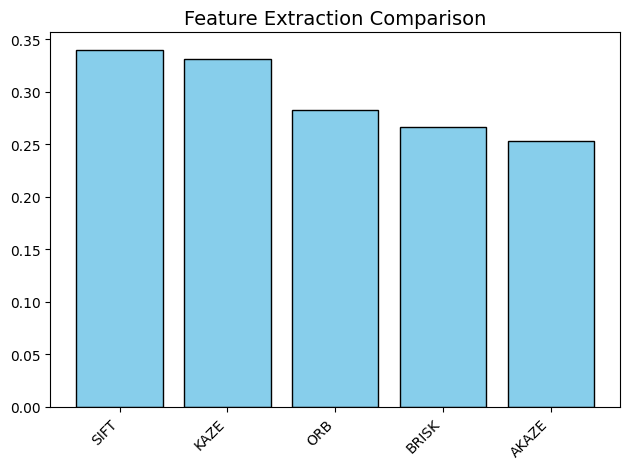

In [19]:
import numpy as np

x = np.array(x)
y = np.array(y)

indices = np.argsort(y)[::-1]
x_sorted = x[indices]
y_sorted = y[indices]

plt.bar(x_sorted, y_sorted, color='skyblue', edgecolor='black')
plt.title('Feature Extraction Comparison', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()